# Question 1: Similarity Grouping
Determine similarity-based groupings among asteroids using selected physical and approach features.

This notebook performs:
1. Data load from shared loader
2. Feature subset selection
3. Numeric scaling
4. K selection support (elbow + silhouette)
5. KMeans grouping
6. Exports for category labeling

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from data_loader import load_neows_data

# Display formatting for cleaner notebook tables
pd.set_option("display.max_columns",None)
pd.set_option("display.width",180)
pd.set_option("display.max_colwidth",80)
pd.set_option("display.expand_frame_repr",False)
pd.set_option("display.float_format","{:,.6f}".format)

In [20]:
# Load shared cleaned data
df_all,df_clean,df_daily=load_neows_data()
print("df_clean shape:",df_clean.shape)
display(df_clean.head(5))

df_clean shape: (60, 15)


,id,neo_reference_id,name,nasa_jpl_url,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous_asteroid,close_approach_date,close_approach_date_full,relative_velocity_kph,miss_distance_km,orbiting_body,is_sentry_object,ingested_at
0,43,54347996,(2023 DZ2),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54347996,24.280000,0.037030,0.082802,0,2026-04-04,2026-04-04 02:04:00,"26,061.586230","1,012,421.611768",Earth,0,2026-04-04 22:29:29
1,51,54607052,(2026 FF7),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54607052,27.472000,0.008514,0.019039,0,2026-04-04,2026-04-04 19:50:00,"47,046.660716","1,771,462.818570",Earth,0,2026-04-04 22:29:29
2,31,54489663,(2024 TB7),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54489663,29.230000,0.003789,0.008473,0,2026-04-07,2026-04-07 14:21:00,"27,085.378477","1,863,693.645372",Earth,0,2026-04-04 22:29:29
3,20,54136202,(2021 GN6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54136202,26.960000,0.010778,0.024101,0,2026-04-06,2026-04-06 08:49:00,"25,375.561708","2,218,033.778217",Earth,0,2026-04-04 22:29:29
4,45,54606897,(2026 FG5),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54606897,25.037000,0.026131,0.058431,0,2026-04-04,2026-04-04 03:27:00,"89,661.031738","3,296,996.238325",Earth,0,2026-04-04 22:29:29


## Feature set for similarity grouping
Use core continuous features only for this phase to keep cluster geometry stable and interpretable.

In [21]:
FEATURE_COLS=[
    "absolute_magnitude_h",
    "estimated_diameter_min_km",
    "estimated_diameter_max_km",
    "relative_velocity_kph",
    "miss_distance_km",
]

missing=[c for c in FEATURE_COLS if c not in df_clean.columns]
if missing:
    raise ValueError(f"Missing required feature columns: {missing}")

df_features=df_clean[FEATURE_COLS].copy()
df_features=df_features.dropna().reset_index(drop=True)
print("Feature matrix shape:",df_features.shape)
display(df_features.describe().T.style.format("{:,.6f}"))

Feature matrix shape: (60, 5)


,count,mean,std,min,25%,50%,75%,max
absolute_magnitude_h,60.000000,25.773317,2.140433,19.440000,24.443500,25.765000,27.230000,30.270000
estimated_diameter_min_km,60.000000,0.031791,0.048449,0.002347,0.009519,0.018688,0.034377,0.343997
estimated_diameter_max_km,60.000000,0.071087,0.108336,0.005249,0.021286,0.041788,0.076870,0.769201
relative_velocity_kph,60.000000,"44,770.560715","24,507.272732","14,378.326912","26,829.430415","36,280.577913","61,969.512103","122,832.326871"
miss_distance_km,60.000000,"33,786,192.509310","22,666,928.601814","1,012,421.611768","14,184,185.062153","31,746,262.166302","51,911,661.053872","73,671,279.944145"


In [22]:
# Standardize numeric features
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_features)
print("Scaled matrix shape:",X_scaled.shape)

Scaled matrix shape: (60, 5)


## K selection diagnostics
Elbow and silhouette are both shown to support defensible K choice.

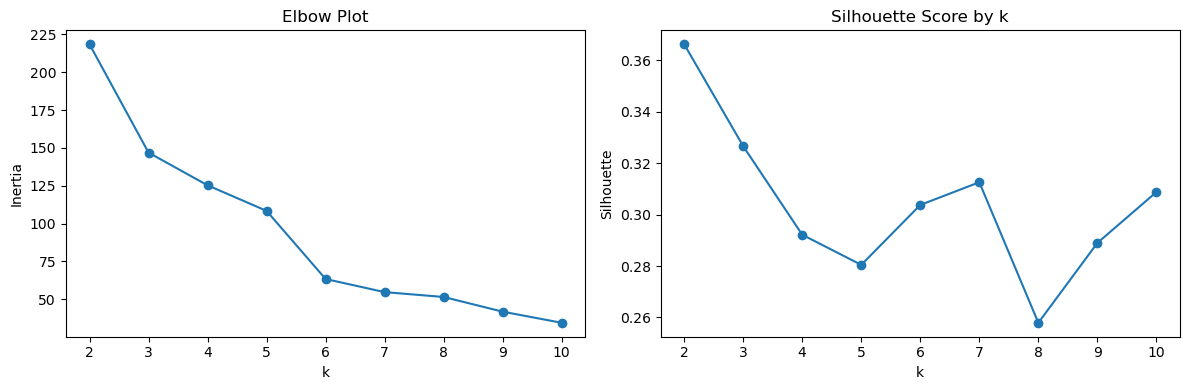

,k,inertia,silhouette
0,2,218.46,0.3662
1,3,146.84,0.3266
2,4,125.25,0.2922
3,5,108.34,0.2804
4,6,63.31,0.3037
5,7,54.65,0.3126
6,8,51.45,0.2579
7,9,41.73,0.2890
8,10,34.38,0.3088


In [23]:
k_values=list(range(2,11))
inertia_vals=[]
silhouette_vals=[]

for k in k_values:
    km=KMeans(n_clusters=k,random_state=42,n_init="auto")
    labels=km.fit_predict(X_scaled)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled,labels))

fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(k_values,inertia_vals,marker="o")
ax[0].set_title("Elbow Plot")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_values,silhouette_vals,marker="o")
ax[1].set_title("Silhouette Score by k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

diag_df=pd.DataFrame({"k":k_values,"inertia":inertia_vals,"silhouette":silhouette_vals})
display(diag_df.style.format({"k":"{:d}","inertia":"{:,.2f}","silhouette":"{:.4f}"}))

In [24]:
# Choose k from diagnostics
K_CHOSEN=4
kmeans=KMeans(n_clusters=K_CHOSEN,random_state=42,n_init="auto")
cluster_labels=kmeans.fit_predict(X_scaled)

df_grouped=df_clean.loc[df_features.index].copy()
df_grouped["cluster_id"]=cluster_labels

print("Cluster counts:")
display(df_grouped["cluster_id"].value_counts().sort_index().rename("count").to_frame())

Cluster counts:


,count
cluster_id,
0,32
1,12
2,5
3,11


In [27]:
# Cluster profile table for categorization step
profile_agg={c:["mean","median","min","max"] for c in FEATURE_COLS}
cluster_profiles=df_grouped.groupby("cluster_id").agg(profile_agg)

# Flatten for readability and easy CSV use
cluster_profiles_flat=cluster_profiles.copy()
cluster_profiles_flat.columns=[f"{a}_{b}" for a,b in cluster_profiles_flat.columns]
display(cluster_profiles_flat.style.format("{:,.6f}"))

,absolute_magnitude_h_mean,absolute_magnitude_h_median,absolute_magnitude_h_min,absolute_magnitude_h_max,estimated_diameter_min_km_mean,estimated_diameter_min_km_median,estimated_diameter_min_km_min,estimated_diameter_min_km_max,estimated_diameter_max_km_mean,estimated_diameter_max_km_median,estimated_diameter_max_km_min,estimated_diameter_max_km_max,relative_velocity_kph_mean,relative_velocity_kph_median,relative_velocity_kph_min,relative_velocity_kph_max,miss_distance_km_mean,miss_distance_km_median,miss_distance_km_min,miss_distance_km_max
cluster_id,,,,,,,,,,,,,,,,,,,,
0,25.957406,25.825000,23.300000,29.230000,0.021800,0.018182,0.003789,0.058151,0.048746,0.040657,0.008473,0.130029,"32,262.581817","29,347.532695","14,378.326912","89,661.031738","17,978,920.074646","20,821,025.824481","1,012,421.611768","41,024,560.829383"
1,25.163333,25.425000,23.020000,27.600000,0.029954,0.021868,0.008027,0.066154,0.066979,0.048899,0.017949,0.147924,"72,588.167042","71,596.156000","31,690.143691","122,832.326871","60,649,843.330495","67,173,874.120518","37,984,978.154599","73,671,279.944145"
2,21.570400,21.840000,19.440000,22.676000,0.150550,0.113908,0.077510,0.343997,0.336641,0.254706,0.173317,0.769201,"71,370.969576","67,585.613437","54,228.525668","96,903.898974","23,466,501.409405","15,335,437.095110","14,601,074.839485","38,044,039.573193"
3,27.813636,27.900000,25.600000,30.270000,0.008878,0.006991,0.002347,0.020163,0.019853,0.015633,0.005249,0.045086,"38,719.833853","36,336.217361","16,302.016410","65,300.015914","55,155,952.832452","55,243,837.580014","34,256,086.672233","70,550,795.833330"


In [26]:
# Export handoff artifacts
out_dir=Path.cwd()/"outputs"
out_dir.mkdir(parents=True,exist_ok=True)

clustered_path=out_dir/"clustered_asteroids.csv"
profiles_path=out_dir/"cluster_profiles.csv"
diag_path=out_dir/"cluster_k_diagnostics.csv"

df_grouped.to_csv(clustered_path,index=False,float_format="%.6f")
cluster_profiles_flat.to_csv(profiles_path,float_format="%.6f")
diag_df.to_csv(diag_path,index=False,float_format="%.6f")

print(f"Saved: {clustered_path}")
print(f"Saved: {profiles_path}")
print(f"Saved: {diag_path}")

Saved: /home/pa11ie/Projects/COSC301/301-space-traffic-control/python/outputs/clustered_asteroids.csv
Saved: /home/pa11ie/Projects/COSC301/301-space-traffic-control/python/outputs/cluster_profiles.csv
Saved: /home/pa11ie/Projects/COSC301/301-space-traffic-control/python/outputs/cluster_k_diagnostics.csv


handoff notes
- `outputs/clustered_asteroids.csv` has row-level `cluster_id` assignments.
- `outputs/cluster_profiles.csv` contains summary stats per cluster.
- `outputs/cluster_k_diagnostics.csv` documents K selection context.